### **Machine Learning for Data Analytics**
### **Assignment 2**
#### Piotr Czech, Filip Miśkiewicz

### **Imports**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import dice_ml
import shap

In [4]:
random_state = 333

In [5]:
df_credit = pd.read_csv('./../datasets/german_credit_risk.csv')

# Drop the unnamed index column if it exists (the first column with row numbers)
if 'Unnamed: 0' in df_credit.columns:
    df_credit = df_credit.drop(columns=['Unnamed: 0'])

# This specific dataset has NaN values in 'Saving accounts' and 'Checking account'.
# We need to fill them so our Neural Network and DiCE don't crash.
df_credit.fillna("Unknown", inplace=True)

# Map target to 1 (good/approved) and 0 (bad/rejected) and force to int
target_col = 'target'
df_credit[target_col] = df_credit['Risk'].map({'good': 1, 'bad': 0}).astype(int)
df_credit.drop(columns=['Risk'], inplace=True)

# Split data FIRST to ensure clean feature lists
X_credit = df_credit.drop(columns=[target_col])
y_credit = df_credit[target_col]

# Define columns based strictly on X_credit
num_cols = X_credit.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_credit.select_dtypes(include=['category', 'object']).columns.tolist()

# Define Preprocessor specifically for the Neural Network
nn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    verbose_feature_names_out=False
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_credit, y_credit, 
    test_size=0.2, 
    random_state=random_state, 
    stratify=y_credit
)

print(f"Train set: {X_train_c.shape}")
print(f"Test set: {X_test_c.shape}")

Train set: (800, 9)
Test set: (200, 9)


In [6]:
# %%
# Define and train the Neural Network Pipeline
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=random_state)

pipeline = Pipeline(steps=[
    ('preprocessor', nn_preprocessor),
    ('classifier', nn_model)
])

pipeline.fit(X_train_c, y_train_c)

# Quick check of accuracy
credit_accuracy = accuracy_score(y_test_c, pipeline.predict(X_test_c))
print(f"Neural Network Accuracy on Test Set: {credit_accuracy:.4f}")

Neural Network Accuracy on Test Set: 0.6550


In [7]:
# %%
# Predict on the test set
y_pred_c = pipeline.predict(X_test_c)

# Filter for rejected applications
rejected_mask = (y_pred_c == 0)
X_rejected = X_test_c[rejected_mask]

# Select the first 5 rejected applications
X_rejected_5 = X_rejected.head(5)

print("Original Data for 5 Rejected Applicants:")
display(X_rejected_5[['Age', 'Credit amount', 'Duration', 'Purpose']])

Original Data for 5 Rejected Applicants:


,Age,Credit amount,Duration,Purpose
257,29,2149,12,radio/TV
599,32,3863,24,business
122,24,1768,12,furniture/equipment
950,40,3590,18,business
744,30,14179,39,furniture/equipment


In [8]:
# %%
# Initialize DiCE Data and Model
d = dice_ml.Data(dataframe=df_credit, continuous_features=num_cols, outcome_name=target_col)
m = dice_ml.Model(model=pipeline, backend="sklearn")

# Initialize the Explainer
exp = dice_ml.Dice(d, m, method="random")

# Define which features the customer can actually negotiate/change
# Updated to match the exact CSV column names
actionable_features = ['Credit amount', 'Duration']

# Generate counterfactuals (we ask for 1 distinct way to get approved per person)
dice_exp = exp.generate_counterfactuals(
    X_rejected_5, 
    total_CFs=1, 
    desired_class="opposite", 
    features_to_vary=actionable_features,
    random_seed=random_state
)

# Visualize the suggested changes
print("Counterfactual Explanations (What to change to get approved):")
dice_exp.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 5/5 [00:00<00:00,  8.85it/s]

Counterfactual Explanations (What to change to get approved):
Query instance (original outcome : 0)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,29,male,2,free,little,little,2149,12,radio/TV,0



Diverse Counterfactual set (new outcome: 1)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,-,-,-,-,-,-,-,5,-,1


...

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,-,-,-,-,-,-,9409,66,-,1


Query instance (original outcome : 0)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,30,male,3,own,Unknown,little,14179,39,furniture/equipment,0



Diverse Counterfactual set (new outcome: 1)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,-,-,-,-,-,-,-,21,-,1


  0%|          | 0/5 [00:00<?, ?it/s]

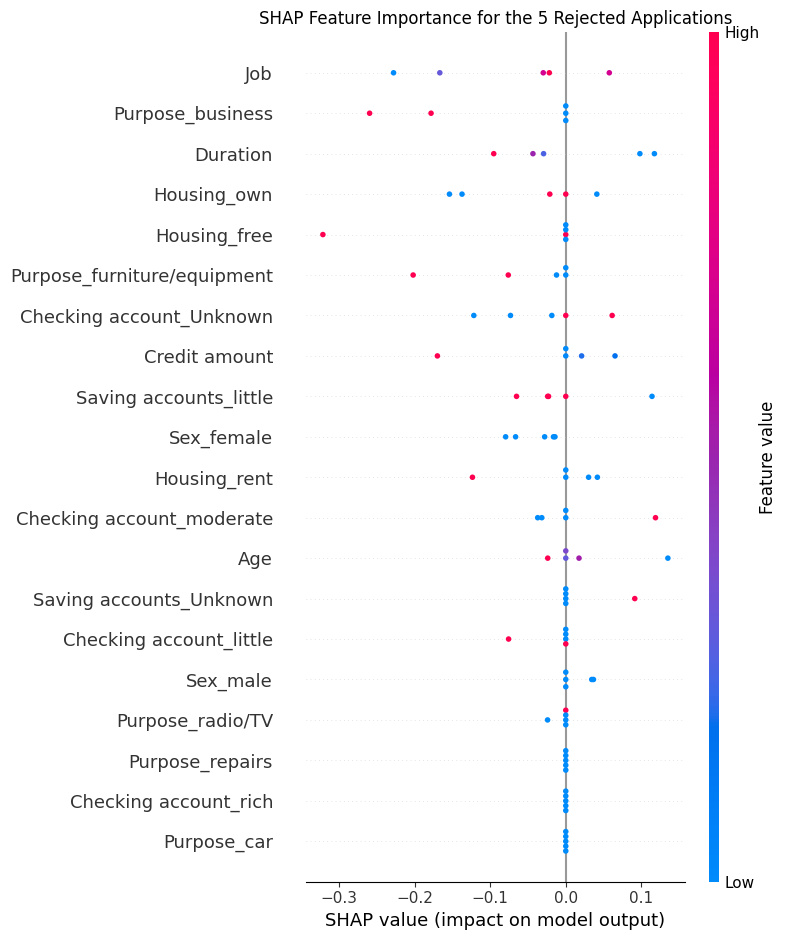


SHAP Force Plot for Applicant 1 (Why they were rejected):


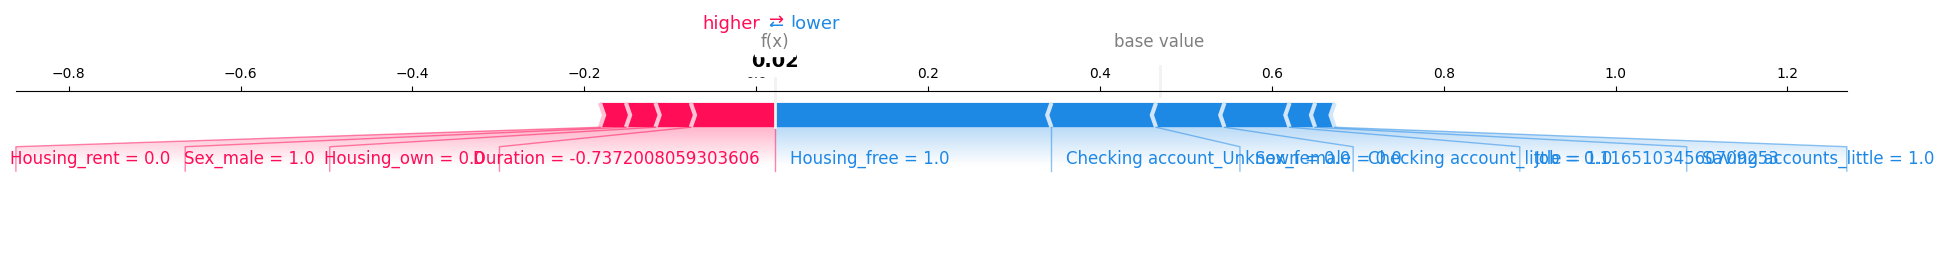

In [9]:
# %%
# Preprocess data for SHAP
X_train_c_enc = nn_preprocessor.transform(X_train_c)
X_rejected_5_enc = nn_preprocessor.transform(X_rejected_5)

# Get feature names from the preprocessor
credit_feature_names = nn_preprocessor.get_feature_names_out()

# Create a background dataset using K-Means to speed up KernelExplainer
background = shap.kmeans(X_train_c_enc, 25)

# Define predict_proba function for SHAP
predict_fn = lambda x: pipeline.named_steps['classifier'].predict_proba(x)

# Initialize SHAP explainer
explainer_nn = shap.KernelExplainer(predict_fn, background)

# Calculate SHAP values for the 5 rejected instances
shap_values_nn = explainer_nn.shap_values(X_rejected_5_enc)

# We want the explanations for the positive class (index 1 / Approved)
shap_values_nn_pos = shap_values_nn[:, 1] if isinstance(shap_values_nn, list) else shap_values_nn[:, :, 1] if len(shap_values_nn.shape) == 3 else shap_values_nn

# Summary plot for the 5 rejected instances
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_nn_pos, X_rejected_5_enc, feature_names=credit_feature_names, show=False)
plt.title("SHAP Feature Importance for the 5 Rejected Applications")
plt.tight_layout()
plt.show()

# Visualize the first rejected person as an example
print("\nSHAP Force Plot for Applicant 1 (Why they were rejected):")

# Safely extract the base value as a float for SHAP v0.20+
expected_val = explainer_nn.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    base_val = float(expected_val[1])
else:
    base_val = float(expected_val)

# Format shap values as a flat numpy array
shap_vals_single = np.array(shap_values_nn_pos[0])

# Plot using positional arguments to prevent the v0.20 error
shap.force_plot(
    base_val,                      
    shap_vals_single,              
    X_rejected_5_enc[0],           
    feature_names=credit_feature_names,
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()